In [1]:
import pandas as pd # import biblioteki pozwalającej na wczytanie danych w formie ramki danych, na których możem wykonywac proste operacje 
import re #biblioteka pozwalająca na wyszukiwania wyrażeń regularnych w tekście
import nltk
nltk.download('stopwords') #ściągnięcie słownika z wyrazami nie niosącymi znaczenia tzw.stopwords
nltk.download('wordnet')
from nltk.corpus import stopwords #import biblioteki, która posiada słownik z stopwordsami
import matplotlib.pyplot as plt #blioteka pozwalająca na wizualizacje danych
from matplotlib import cm #import palety kolorów biblioteki matplotlib
import seaborn as sns #blioteka pozwalająca na wizualizacje danych
from wordcloud import WordCloud #biblioteka pozwalającca na tworzenie chmury słów
from nltk.stem import PorterStemmer #biblioteka pozwalajaca na stemantyzację
from nltk.stem.wordnet import WordNetLemmatizer #biblioteka pozwalajaca na lemantyzację
import collections # biblioteka pozwalająca na zliczanie słów, bigramów, trigramów
from nltk import bigrams #biblioteka do tworzenia bigramów
import pickle #biblioteka do tworzenia i otwierania plików w formacie pickle
import stylecloud #biblioteka do tworzenia chmury słów
from googletrans import Translator #biblioteka do tłumaczenia napisanego tekstu na inny język lub detekcji języka

plt.style.use("seaborn-v0_8-whitegrid")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hania\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hania\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
data = pd.read_csv("data_clean.csv", index_col = 0)

In [3]:
#jezeli w wiersz jest postem to ma tylko title, nie ma body
((data["type"]=="posts") & (data["body"].notna())).any()
#jezeli wiersz jest komentarzem to ma tylko body, nie ma title
((data["type"]=="comment") & (data["title"].notna())).any()

#krocej zapisane ze nie ma takiego wiersza w ktorym i w kolumnie title i body jest cokolwiek
((data["title"].notna()) & (data["body"].notna())).any()

np.False_

In [4]:
data["tresc"] = data[["title","body"]].fillna("").agg(" ".join, axis=1).str.strip() #łączy nam tekst z obu kolumn w jedna kolumne "tresc"

# ANALIZA DLA MILEY CYRUS OD 2024

In [5]:
data_miley_24_26 = data[(data["subreddit"] != "hannahmontana") & (data['year'] >= 2024)]
data_miley_24_26.head(5)

,type,subreddit,date,year,id,parent_id,author,title,body,score,over_18,tresc
58143,comments,mileycyrus,2024-01-01,2024,kfrs0x4,18u0oga,Mindless-General-538,NaN,so talented and such a perfect body,1,NaN,so talented and such a perfect body
58144,comments,mileycyrus,2024-01-01,2024,kfsn8v3,100c93c,KCFL1,NaN,What happened to her NYE show this year??,1,NaN,What happened to her NYE show this year??
58146,comments,mileycyrus,2024-01-02,2024,kfyf76l,kcwkmsb,mileycyrus4,NaN,Hello,1,NaN,Hello
58147,comments,mileycyrus,2024-01-02,2024,kfyf8d5,kd0llhm,mileycyrus4,NaN,Hello,1,NaN,Hello
58148,comments,mileycyrus,2024-01-02,2024,kfyf98g,kfhnge8,mileycyrus4,NaN,Hello,1,NaN,Hello


In [6]:
data_miley_24_26["year"].value_counts()

year
2024    13783
2025    12694
2026     5691
Name: count, dtype: int64

In [7]:
data_miley_24_26["subreddit"].value_counts()

subreddit
queenmileycyrus    24096
mileycyrus          4102
miley               3970
Name: count, dtype: int64

In [8]:
data_miley_24_26_df = pd.DataFrame(data_miley_24_26, columns=['tresc'])
data_miley_24_26_df.head(5)

,tresc
58143,so talented and such a perfect body
58144,What happened to her NYE show this year??
58146,Hello
58147,Hello
58148,Hello


In [9]:
dictionary = {
    "dont": "don't",
    "didnt": "didn't",
    "wasnt": "wasn't",
    "werent": "weren't",
    "shes": "she's",
    "ive": "I've",
    "cant": "can't",
    "hes": "he's",
    "isnt": "isn't",
    "arent": "aren't"
}

def normalize_text(text):
    new_words = text.split()
    new_words = [dictionary.get(w, w) for w in new_words]
    return " ".join(new_words)

In [10]:
# Łączymy cały oczyszczony tekst w jedną całość, oddzielając posty nową linią
caly_tekst = "\n".join(data_miley_24_26_df['tresc'].astype(str))

# Zapisujemy to do pliku tekstowego na dysku
with open("sprawdzenie_tekstu_miley.txt", "w", encoding="utf-8") as f:
    f.write(caly_tekst)

print("Plik został zapisany! Wejdź do folderu projektu i otwórz 'sprawdzenie_tekstu_miley.txt' w Notatniku.")

Plik został zapisany! Wejdź do folderu projektu i otwórz 'sprawdzenie_tekstu_miley.txt' w Notatniku.


In [11]:
import re

wulgaryzmy_mapa = {
    'fucking': 'f*cking',
    'fuck': 'f*ck',
    'shitty': 'sh*tty',
    'shit': 'sh*t',
    'bitches': 'b*tches',
    'bitch': 'b*tch',
    'ass': 'a*s',
    'tits': 't*ts',
    'pussy': 'p*ssy',
    'cum': 'c*m',
    'cock': 'c*ck',
    'sex': 's*x'
}

def cenzuruj_wulgaryzmy(text):
    if not isinstance(text, str):
        return text
    
    # Python bierze słowo po słowie z Twojej listy i podmienia na bezpieczną wersję
    for slowo, zamiennik in wulgaryzmy_mapa.items():
        wzorzec = r'\b' + slowo + r'\b'
        text = re.sub(wzorzec, zamiennik, text, flags=re.IGNORECASE)
    return text

In [12]:
#Usuwanie stopwords
def remove_my_stopwords(text):
    stop_words = stopwords.words("english") 
    stop_words.extend(["oah", "haha", "hey", "yeah", "oh", "lol", "omg", "ain't", "im", "that's", "i've", "I've", "miley", "mileys", "miley's", "cyrus", "would", "could", "doesnt", "doesn't", "can't", "also", "pic", "dm", "ig", "tho", "tbh", "imo", "id", "thats", "wow", "us", "got"])
    filtred_words=[]
    for word in text.split():
        if word not in stop_words:
            filtred_words.append(word)
    return filtred_words

In [13]:
data_miley_24_26_string = " ".join(data_miley_24_26_df['tresc'].fillna(""))

In [14]:
#oczyszczenie
import emoji

data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].fillna("")
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: str(x).lower())
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub('(http\S+)', "", x)) #linki
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub('#(\w+)', "", x)) #hashtagi
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: emoji.replace_emoji(x, "")) #emoji
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub('\d+', "", x)) #cyfry
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub(r"\s+", " ", x)) #spacje
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub("[^\w\s']+", "", x)) #znaki interpunkcyjne i ich ciagi np (???!!!) ale zachowuje apostrofy
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: str(x).strip()) #spacje okalajace wyraz otacza 
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(normalize_text)
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(cenzuruj_wulgaryzmy)
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: remove_my_stopwords(x))
data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: " ".join(x))

<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\w'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\w'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\w'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\w'
C:\Users\hania\AppData\Local\Temp\ipykernel_11488\1320927213.py:6: SyntaxWarning: invalid escape sequence '\S'
  data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub('(http\S+)', "", x)) #linki
C:\Users\hania\AppData\Local\Temp\ipykernel_11488\1320927213.py:8: SyntaxWarning: invalid escape sequence '\w'
  data_miley_24_26_df['tresc'] = data_miley_24_26_df['tresc'].apply(lambda x: re.sub('#(\w+)', "", x)) #hashtagi
C:\Users\hania\AppData\Local\Temp\ipykernel_11488\1320927213.py:10: SyntaxWarning: invalid escape sequence '\d'
  data_miley_24_26_df['tresc'] = dat

In [15]:
data_miley_24_26_str = data_miley_24_26_df['tresc'].fillna("").str.lower().str.split().explode().dropna().tolist()
data_miley_24_26_str

['talented',
 'perfect',
 'body',
 'happened',
 'nye',
 'show',
 'year',
 'hello',
 'hello',
 'hello',
 'hello',
 'hello',
 'hello',
 'hello',
 'text',
 'privately',
 'hello',
 'guess',
 'sent',
 'invite',
 'text',
 'privately',
 'hi',
 'hello',
 'hello',
 'hello',
 'hello',
 'hello',
 'hello',
 'hello',
 'hello',
 'hello',
 'hello',
 'hello',
 'hello',
 'hello',
 'happy',
 'new',
 'year',
 'hello',
 'find',
 'really',
 'odd',
 'writing',
 'usually',
 'chat',
 'fans',
 'reading',
 'comment',
 'fan',
 'page',
 'realized',
 'much',
 'like',
 'follow',
 'page',
 'thanks',
 'support',
 'positive',
 'vibes',
 'sup',
 'fellow',
 'worshiper',
 'favourite',
 'look',
 'looks',
 'pretty',
 'pics',
 'tamed',
 'tamed',
 'miss',
 'days',
 'thank',
 'much',
 'love',
 'support',
 'send',
 'direct',
 'message',
 'send',
 'direct',
 'message',
 'thank',
 'love',
 'support',
 'gorgeous',
 'sexiest',
 'perfect',
 'woman',
 'alive',
 'bye',
 'bye',
 'bye',
 'bye',
 'bye',
 'seek',
 'help',
 'cool',
 'scho

<Axes: xlabel='slowa'>

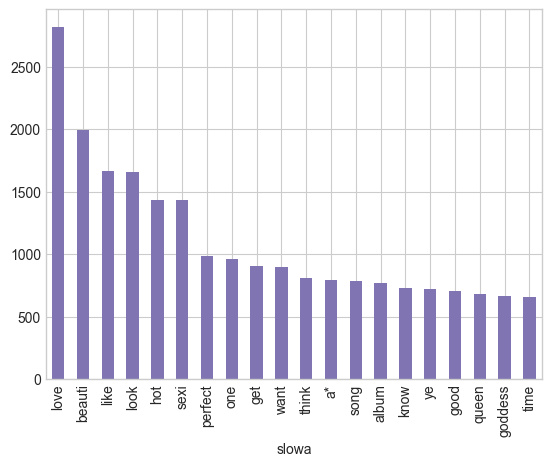

In [16]:
#proces stemantyzacji - sprowadzanie słów do ich rdzeni
#Wywołaj konwerter pozwalający na stemming tekstu za pomocą funkcji PorterStemmer()
ps = PorterStemmer()
#Stwórz pustą listę o nazwie stemmed_words
stemmed_words = []
#Wykonaj pętle po słowach, która będzie każde słowo w bloku tekstu sprowadzać do rdzenia i zapisz je do listy stemmed_words
for word in data_miley_24_26_str:
    stemmed_words.append(ps.stem(word))

lista_slow_stem = pd.DataFrame(stemmed_words)
lista_slow_stem.rename(columns = {0:"slowa"}, inplace=True)
lista_slow_stem.slowa.value_counts().head(20).plot(kind = "bar", color = "#8074B2")

In [17]:
lista_slow_stem.slowa.value_counts().head(40)

slowa
love       2816
beauti     1990
like       1667
look       1657
hot        1435
sexi       1434
perfect     983
one         960
get         907
want        900
think       810
a*          795
song        781
album       767
know        727
ye          717
good        704
queen       683
goddess     665
time        655
see         624
make        618
bodi        605
alway       584
gorgeou     545
amaz        530
best        520
realli      502
much        499
someth      459
go          449
need        444
absolut     440
f*ck        427
show        426
leg         424
face        419
damn        408
great       404
woman       397
Name: count, dtype: int64

<Axes: xlabel='slowa'>

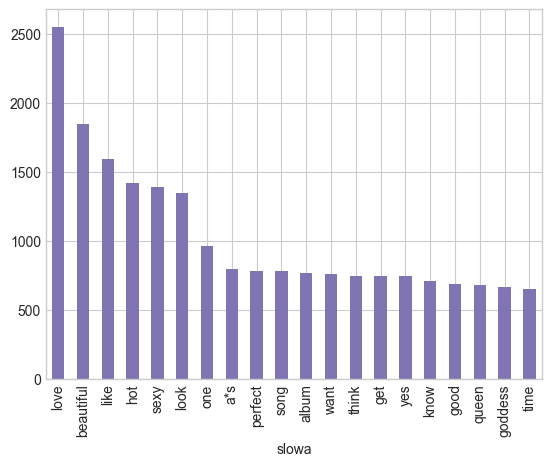

In [18]:
#Lemnatyzacja - sprowadzenie słów do wersji podstawowej
wnl = WordNetLemmatizer()

lemmed_words = []

for word in data_miley_24_26_str:
    lemmed_words.append(wnl.lemmatize(word))
                        
lista_slow_lem = pd.DataFrame(lemmed_words)
lista_slow_lem.rename(columns = {0:"slowa"}, inplace=True)
lista_slow_lem.slowa.value_counts().head(20).plot(kind = "bar", color = "#8074B2")

In [19]:
lista_slow_lem.slowa.value_counts().head(40)

slowa
love         2553
beautiful    1846
like         1596
hot          1420
sexy         1394
look         1349
one           960
a*s           795
perfect       783
song          781
album         767
want          763
think         747
get           745
yes           745
know          709
good          688
queen         683
goddess       665
time          652
body          603
always        582
make          547
gorgeous      545
amazing       526
see           526
best          520
really        502
much          499
woman         463
something     456
f*ck          427
leg           422
face          413
need          409
damn          404
great         399
every         384
new           378
way           377
Name: count, dtype: int64

## LISTA TOP SŁÓW 

In [20]:
df = pd.DataFrame(data_miley_24_26_df, columns = ['tresc'])
df.head()

,tresc
58143,talented perfect body
58144,happened nye show year
58146,hello
58147,hello
58148,hello


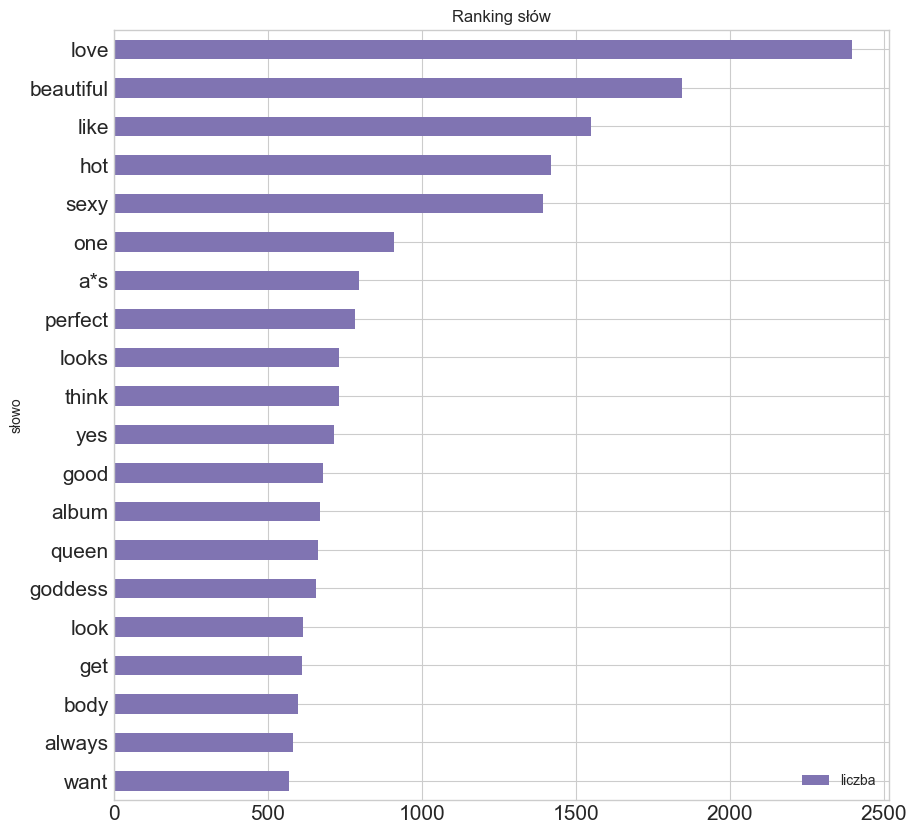

In [21]:
#statystykA częstości występowania słów w postach/komentarzach ze slowek hannahmontana
words = pd.DataFrame(data_miley_24_26_str).value_counts().head(20).rename_axis("słowo").reset_index(name="liczba")
#Zwizualizuj otrzymane wyniki
words.sort_values(by='liczba').plot.barh(x='słowo',y='liczba', figsize=(10,10), fontsize=15, title='Ranking słów', color="#8074B2");

## CHMURA SŁÓW

In [22]:
word_cloud_words = pd.DataFrame(data_miley_24_26_str).value_counts().head(80).rename_axis("word").reset_index(name="count")
word_cloud_words
wystapienia_miley_24_26 = dict(zip(word_cloud_words["word"], word_cloud_words["count"]))
wystapienia_miley_24_26

{'love': 2395,
 'beautiful': 1846,
 'like': 1550,
 'hot': 1420,
 'sexy': 1394,
 'one': 910,
 'a*s': 795,
 'perfect': 783,
 'looks': 733,
 'think': 730,
 'yes': 715,
 'good': 680,
 'album': 669,
 'queen': 665,
 'goddess': 656,
 'look': 616,
 'get': 610,
 'body': 597,
 'always': 582,
 'want': 568,
 'gorgeous': 545,
 'time': 534,
 'amazing': 526,
 'see': 522,
 'best': 518,
 'know': 517,
 'really': 502,
 'song': 500,
 'much': 499,
 'something': 456,
 'f*ck': 427,
 'legs': 414,
 'damn': 404,
 'face': 400,
 'great': 399,
 'woman': 394,
 'every': 384,
 'new': 378,
 'even': 373,
 'way': 354,
 'absolutely': 348,
 'right': 347,
 'ever': 341,
 'god': 336,
 'people': 334,
 'never': 334,
 'still': 330,
 'definitely': 323,
 'back': 318,
 'music': 316,
 'sure': 316,
 'little': 312,
 't*ts': 300,
 'make': 288,
 'hard': 288,
 'wish': 287,
 'songs': 281,
 'need': 275,
 'bad': 267,
 'tongue': 266,
 'better': 265,
 'day': 264,
 'makes': 259,
 'well': 256,
 'era': 252,
 'girl': 251,
 'f*cking': 251,
 'nice

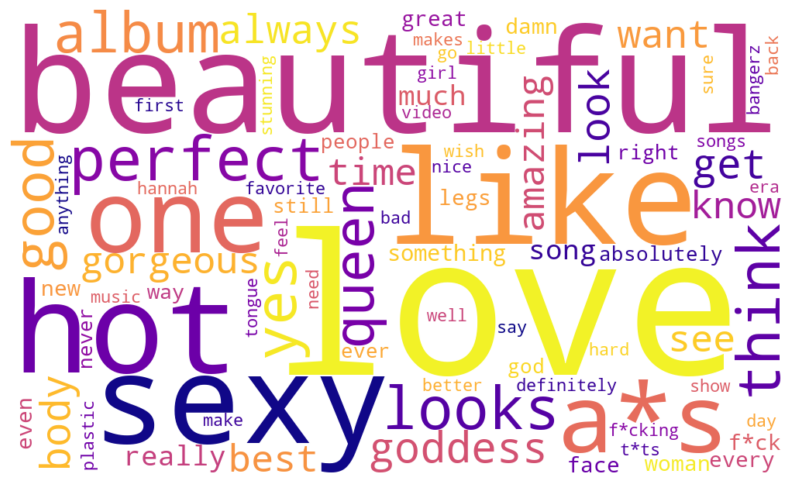

In [23]:
#Utwórz chmurę słów
#Wywołanie obiektu odpowiedzialnego za tworzenie chmury słów WordCloud()
plt.figure(figsize=(10,10))
wc= WordCloud(background_color ='white', max_words = 80, width=1000, height=600, colormap = cm.plasma).generate_from_frequencies(wystapienia_miley_24_26)
#Utwórz chmurę słow za pomocą funkcj wc.generate(), a następnie ją wyświetl za pomocą funkcji plt.imshow()
plt.imshow(wc, interpolation='bilinear')
plt.axis('off');

In [24]:
import numpy as np
from PIL import Image

In [25]:
mask = np.array(Image.open("wordcloud-masks/mileycyrus wrecking ball mask.png").convert("L"))
mask = np.where(mask > 100, 255, 0)

In [26]:
colors = ["#dabcff","#deacde","#9e4a9e","#ffc370","#ffc6d0","#800080","#b266b2","#a64ca6","#b266b2"]
color_function = lambda *args, **kwargs: np.random.choice(colors)

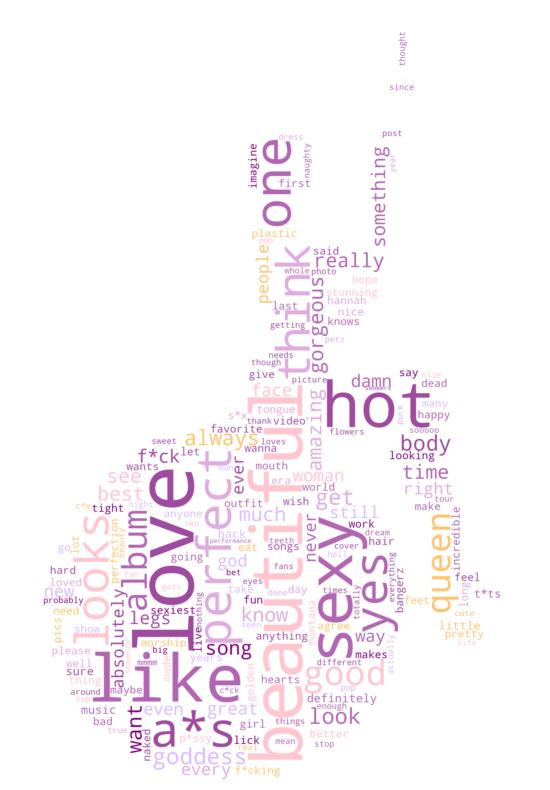

In [27]:
word_cloud_words = pd.DataFrame(data_miley_24_26_str).value_counts().head(200).rename_axis("word").reset_index(name="count")
word_cloud_words
wystapienia_miley_24_26 = dict(zip(word_cloud_words["word"], word_cloud_words["count"]))
wystapienia_miley_24_26
plt.figure(figsize=(10,10))
wc= WordCloud(background_color ="white", mask=mask,scale = 1.5,color_func=color_function, max_words = 190, width=1000, height=600, colormap = cm.plasma).generate_from_frequencies(wystapienia_miley_24_26)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off');

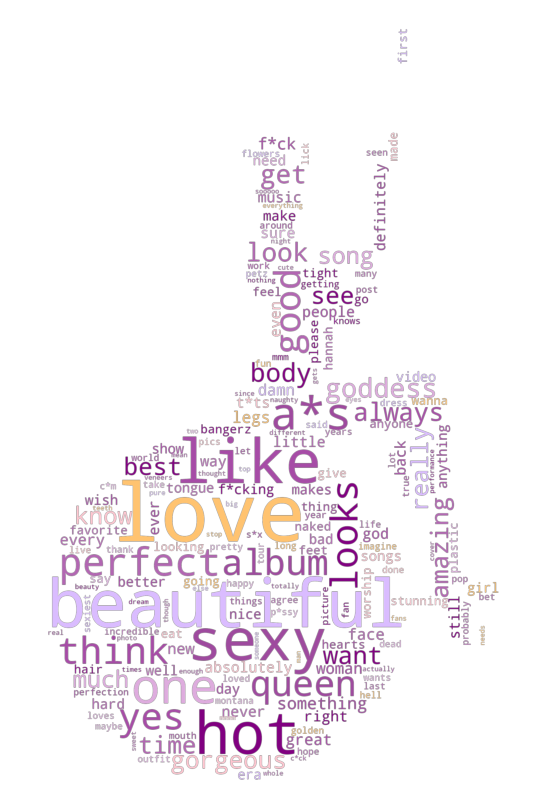

In [28]:
word_cloud_words = pd.DataFrame(data_miley_24_26_str).value_counts().head(200).rename_axis("word").reset_index(name="count")
word_cloud_words
wystapienia_miley_24_26 = dict(zip(word_cloud_words["word"], word_cloud_words["count"]))
wystapienia_miley_24_26
plt.figure(figsize=(10,10))
wc= WordCloud(background_color = None,mode = "RGBA", mask=mask,scale = 1.5,color_func=color_function, max_words = 190, width=1000, height=600, colormap = cm.plasma).generate_from_frequencies(wystapienia_miley_24_26)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off');

In [51]:
img = Image.open("wordcloud-masks/mileycyrus wrecking ball mask.png").convert("RGB")
arr = np.array(img)

#zeby tło to był taki beżowy/cielisty kolor
beige = np.array([255, 251, 242])

mask = arr.mean(axis=2) < 250
arr[mask] = arr[mask] * 0.1 + beige * 0.9

out = Image.fromarray(arr)
out.save("output_miley_24_26.png")

In [52]:
#tło
background = Image.open("output_miley_24_26.png").convert("RGBA")

#stworzony wczesniej wordcloud
wordcloud = Image.open("wordcloud-masks/mileycyrus2426_output_p.png").convert("RGBA") # XXX skąd to ???

wordcloud = wordcloud.resize(background.size)
wordcloud.putalpha(180)

result = Image.alpha_composite(background, wordcloud)

result.save("final_miley_24_26.png")

## ANALIZA WYDŹWIĘKU

In [31]:
from textblob import TextBlob
from nltk.corpus import stopwords, twitter_samples
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import seaborn as sns
import numpy as np
import re
import matplotlib.pyplot as plt
import pandas as pd
import nltk

In [32]:
from nltk.corpus import stopwords

stop = set(stopwords.words("english"))

safe_stopwords = stop - {
    "not", "no", "nor",
    "don't", "didn't", "wasn't", "won't", "can't",
    "isn't", "aren't", "couldn't", "wouldn't"
}

In [33]:
df = pd.DataFrame(data_miley_24_26, columns=['tresc'])
df.head()

,tresc
58143,so talented and such a perfect body
58144,What happened to her NYE show this year??
58146,Hello
58147,Hello
58148,Hello


In [34]:
#Usuwanie stopwords
def remove_my_stopwords(text):
    stop_words = safe_stopwords
    stop_words.update({"oah", "haha", "hey", "yeah", "oh", "lol", "omg", "im"})
    filtred_words=[]
    for word in text.split():
        if word not in stop_words:
            filtred_words.append(word)
    return filtred_words

In [35]:
#oczyszczenie
import emoji

df['tresc'] = df['tresc'].fillna("")
df['tresc'] = df['tresc'].apply(lambda x: str(x).lower())
df['tresc'] = df['tresc'].apply(lambda x: re.sub('(http\S+)', "", x)) #linki
df['tresc'] = df['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
df['tresc'] = df['tresc'].apply(lambda x: re.sub('#(\w+)', "", x)) #hashtagi
df['tresc'] = df['tresc'].apply(lambda x: emoji.replace_emoji(x, "")) #emoji
df['tresc'] = df['tresc'].apply(lambda x: re.sub('\d+', "", x)) #cyfry
df['tresc'] = df['tresc'].apply(lambda x: re.sub(r"\s+", " ", x)) #spacje
df['tresc'] = df['tresc'].apply(lambda x: re.sub("[^\w\s']+", "", x)) #znaki interpunkcyjne i ich ciagi np (???!!!) ale zachowuje apostrofy
df['tresc'] = df['tresc'].apply(lambda x: str(x).strip()) #spacje okalajace wyraz otacza 
df['tresc'] = df['tresc'].apply(normalize_text)
df['tresc'] = df['tresc'].apply(lambda x: remove_my_stopwords(x))
df['tresc'] = df['tresc'].apply(lambda x: " ".join(x))

<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\w'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\w'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\w'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\w'
C:\Users\hania\AppData\Local\Temp\ipykernel_11488\821319796.py:6: SyntaxWarning: invalid escape sequence '\S'
  df['tresc'] = df['tresc'].apply(lambda x: re.sub('(http\S+)', "", x)) #linki
C:\Users\hania\AppData\Local\Temp\ipykernel_11488\821319796.py:8: SyntaxWarning: invalid escape sequence '\w'
  df['tresc'] = df['tresc'].apply(lambda x: re.sub('#(\w+)', "", x)) #hashtagi
C:\Users\hania\AppData\Local\Temp\ipykernel_11488\821319796.py:10: SyntaxWarning: invalid escape sequence '\d'
  df['tresc'] = df['tresc'].apply(lambda x: re.sub('\d+', "", x)) #cyfry
C:\Users\hania\AppData\Local\Temp\

In [36]:
miley_24_26_sentiment = df['tresc'].fillna("").str.lower().str.split().explode().dropna()

In [37]:
tekst = " ".join(miley_24_26_sentiment)
tekst

"talented perfect body happened nye show year hello hello hello hello hello hello hello could text privately hello guess sent invite could text privately hi hello hello hello hello hello hello hello hello hello hello hello hello hello happy new year hello find really odd writing don't usually chat fans reading comment fan page realized much like follow page thanks support positive vibes sup fellow miley worshiper favourite miley look looks pretty pics can't tamed can't tamed miss days thank much love support send direct message send direct message thank love support gorgeous sexiest perfect woman alive bye bye bye bye bye seek help cool school missing microscope viewing stop ruining photos ai upscaling beautiful sexy totally agree amazing amazing love short hair miley damn good hottest sexiest woman alive goddess perfection god spectacularly beautiful endlessly sexy know might sound odd outfit think well wwe event thanks love support send direct message thank much love support send dir

In [38]:
#Częstość występowania pozytywnych słów w korpusie
wystapienia = [] #utworzenie pustej listy

with open('pozytywne_slowa.txt') as file: #otworzenie pliku tekstoweo z pozytywnymi słowami
    pozytywne_slowa = file.read().split('\n') #zapisanie pozytywnych słów do zmiennej

    for slowo in pozytywne_slowa: #pętl po słowach pozytywnych
        wystapienia.append(tekst.count(slowo.strip())) #zliczenie słów pozytywnych w tekście za pomocą funkcji count
        
pozytywne_slowa_wystapienia = pd.DataFrame(wystapienia, index=pozytywne_slowa, columns=['liczba']) #zapisanie występujących pozytywnych słów do ramki danych

In [39]:
#Wyfiltruj pozytywne słowa z tekstu (gdy słowo występuje chociaż raz)
pozytywne_conjamniej_raz = pozytywne_slowa_wystapienia[pozytywne_slowa_wystapienia.liczba >1]
pozytywne_conjamniej_raz.sort_values(by = "liczba", ascending = False)

,liczba
,924177
love,2891
hot,1993
beautiful,1873
like,1691
...,...
victorious,2
upscale,2
accomplish,2
zeal,2


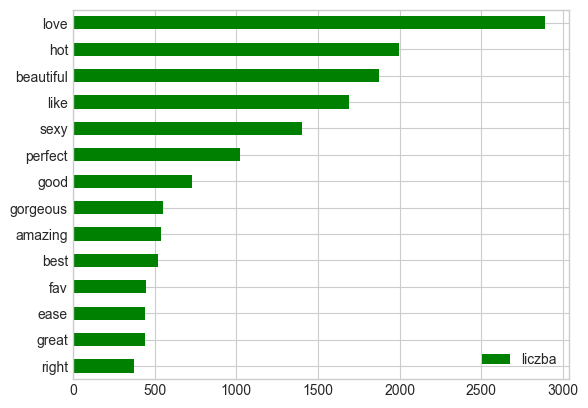

In [40]:
#Zwizualizuj wykrytych 14 pozytywnych słów
pozytywne_conjamniej_raz.sort_values(by = "liczba", ascending = False)[1:15].plot(kind = 'barh', color = 'green')
plt.gca().invert_yaxis()

In [41]:
#Częstość występowania pozytywnych słów w korpusie
wystapienia = [] #utworzenie pustej listy

with open('negatywne_slowa.txt', encoding = "latin1") as file: #otworzenie pliku tekstoweo z pozytywnymi słowami
    
    negatywne_slowa = file.read().split('\n') #zapisanie pozytywnych słów do zmiennej

    for slowo in negatywne_slowa: #pętl po słowach pozytywnych
        wystapienia.append(tekst.count(slowo.strip())) #zliczenie słów pozytywnych w tekście za pomocą funkcji count
        
negatywne_slowa_wystapienia = pd.DataFrame(wystapienia, index=negatywne_slowa, columns=['liczba']) #zapisanie występujących pozytywnych słów do ramki danych

In [42]:
negatywne_conjamniej_raz = negatywne_slowa_wystapienia[negatywne_slowa_wystapienia.liczba >1]
negatywne_conjamniej_raz.sort_values(by = "liczba", ascending = False)

,liczba
,924177
bum,805
ugh,795
fuck,775
odd,723
...,...
reject,2
wreak,2
rhetoric,2
abusive,2


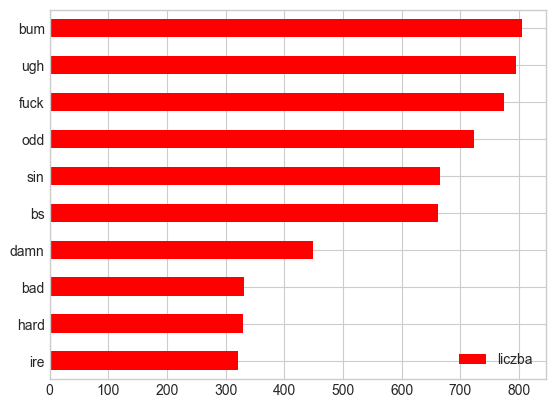

In [43]:
negatywne_conjamniej_raz.sort_values(by = "liczba", ascending = False)[1:11].plot(kind = 'barh', color = 'red')
plt.gca().invert_yaxis()

In [44]:
#VADER

In [45]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
#Wywołaj i przypisz do zmiennej model za pomocą funkcji SentimentIntensityAnalyzer()
sia = SentimentIntensityAnalyzer()
#Sprawdź przypisany sentyment do słow zwartych w słowniku Vadera za pomocą funkcji oboiekt.lexicon
sia.lexicon
data_miley_24_26["tresc"] = data_miley_24_26['tresc'].apply(normalize_text)
data_miley_24_26["tresc"] = data_miley_24_26['tresc'].apply(lambda x: re.sub(r"http\S+|www\S+", "", x)) #linki, strony internetowe
data_miley_24_26["tresc"] = data_miley_24_26['tresc'].apply(lambda x: re.sub(r'@\w+', '', x)) #oznaczenia
data_miley_24_26["vader"] = data_miley_24_26['tresc'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
data_miley_24_26.head()

,type,subreddit,date,year,id,parent_id,author,title,body,score,over_18,tresc,vader
58143,comments,mileycyrus,2024-01-01,2024,kfrs0x4,18u0oga,Mindless-General-538,NaN,so talented and such a perfect body,1,NaN,so talented and such a perfect body,0.807
58144,comments,mileycyrus,2024-01-01,2024,kfsn8v3,100c93c,KCFL1,NaN,What happened to her NYE show this year??,1,NaN,What happened to her NYE show this year??,0.000
58146,comments,mileycyrus,2024-01-02,2024,kfyf76l,kcwkmsb,mileycyrus4,NaN,Hello,1,NaN,Hello,0.000
58147,comments,mileycyrus,2024-01-02,2024,kfyf8d5,kd0llhm,mileycyrus4,NaN,Hello,1,NaN,Hello,0.000
58148,comments,mileycyrus,2024-01-02,2024,kfyf98g,kfhnge8,mileycyrus4,NaN,Hello,1,NaN,Hello,0.000


<Axes: >

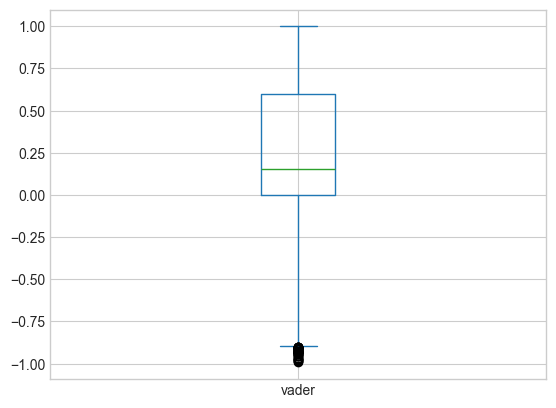

In [46]:
data_miley_24_26['vader'].plot.box()

<Axes: ylabel='vader'>

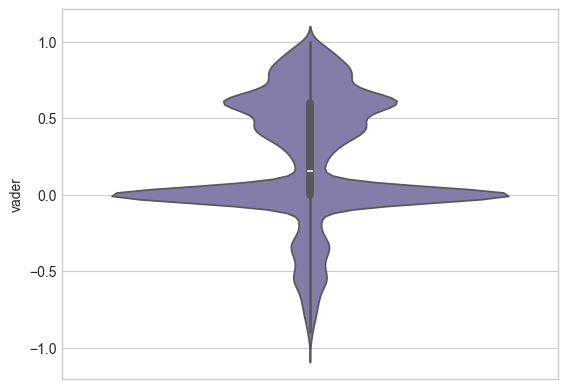

In [47]:
sns.violinplot(y=data_miley_24_26['vader'], color = "#8074B2")

In [48]:
data_miley_24_26.loc[:, "label"] = data_miley_24_26["vader"].apply(
    lambda x: "pos" if x >= 0.05 else
              "neg" if x <= -0.05 else
              "neu"
)

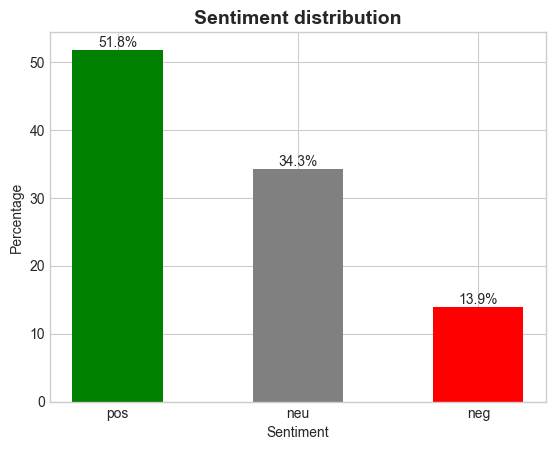

In [49]:
counts = data_miley_24_26["label"].value_counts(normalize=True) * 100

bars = plt.bar(counts.index, counts.values, color=["green", "gray", "red"], width = 0.5)

plt.style.use("seaborn-v0_8-whitegrid")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:.1f}%",
        ha="center",
        va="bottom"
    )
plt.title("Sentiment distribution", fontsize=14, weight="bold")
plt.xlabel("Sentiment")
plt.ylabel("Percentage")

plt.show()

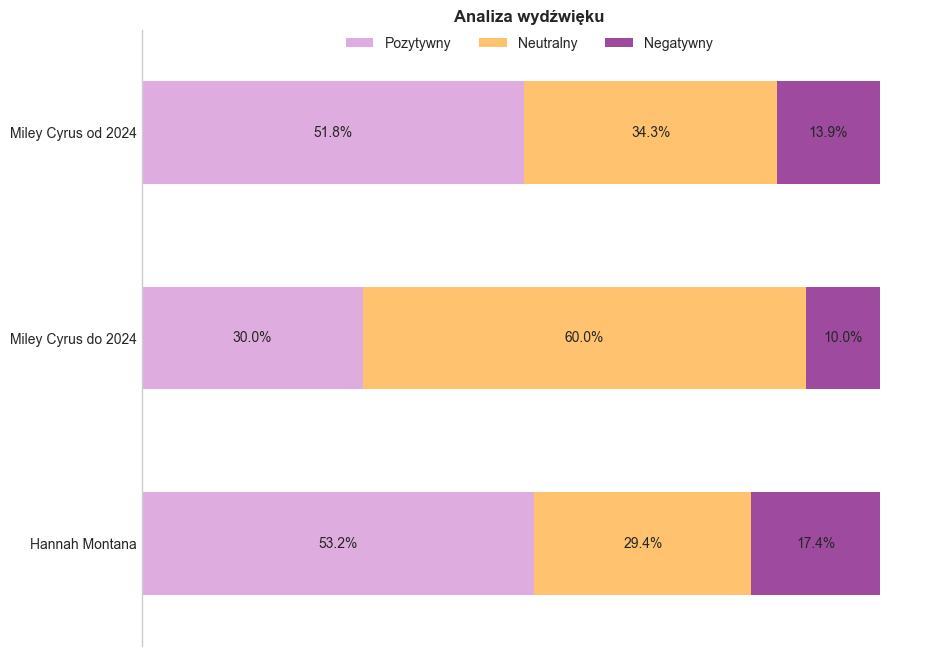

In [50]:
category_names = ["Pozytywny", "Neutralny", "Negatywny"]

colors = ["#deacde", "#ffc370","#9e4a9e"]

df = pd.DataFrame({
    "Pozytywny": [53.2, 30, 51.8],
    "Neutralny":[29.4, 60, 34.3],
    "Negatywny": [17.4, 10, 13.9]
}, index = ["Hannah Montana", "Miley Cyrus do 2024", "Miley Cyrus od 2024"])


ax = df.plot(kind = "barh",
             stacked = True,
             color = colors,
             figsize = (10,8))

for container in ax.containers:
    ax.bar_label(container,
                label_type = "center",
                labels = [f"{bar.get_width():.1f}%" for bar in container
    ])

ax.xaxis.set_visible(False)

ax.set_title("Analiza wydźwięku", fontweight = "bold")
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=len(df.columns),
    frameon=False
)


plt.show()